# day09 - Reparameterization Trick and Bayes-by-Backprop

In this notebook, we'll cover

* Part 0: Recap of Variational Inference
* Part 1: Transformations of Random Variables
* Part 2: Reparameterization Trick for Expectations
* Part 3: Reparameterization Trick for Gradients of Expectations
* Part 4: How to do gradient descent when variances need to stay positive?
* Part 5: Bayes by Backprop Algorithm: VI for Neural Net Regression
* Part 6: Automatic Differentiation Variational Inference (ADVI)

Mostly a focus on core concepts. In HW4 we'll operationalize these ideas to fit an autoencoder.

# Prerequisites

Check out today's reading

* [Weight Uncertainty in Neural Networks](https://arxiv.org/pdf/1601.00670.pdf) by Blundell et al.
* * Esp. [Algorithm 1: "Bayes by Backprop](https://arxiv.org/pdf/1401.0118.pdf#page=3)

We'll try to use the same notation as in earlier days of this class, so the notation here may differ from the background reading.

# Requirements

There are two ways to run this notebook

<table style="table-medium">
    <tr>
        <td style="align:left; text-align:left;"> <h2> Run in-browser (no install necessary) </h2>
        </td>
        <td style="align:left; text-align:left;"> <h2> Run locally on your computer </h2>
        </td>        
    </tr>
    <tr>
         <td style="align:left; text-align:left;">
             <p>You can use <a href="https://colab.research.google.com/">Google Colab </a> </p>
             <p>You'll need:</p>
             <ul>
             <li> internet connection </li>
             <li>  Modern browser (Firefox, Chrome, Safari, Edge, etc) </li>
             <li> Google account </li>
             <li> Warning: session will timeout after 12 hours, or sooner if inactive </li>
             <li> Plan to save work if you want it later </li>
         </ul></td>
         <td style="align:left; text-align:left;">
             <p>You can use <a href="https://jupyter.org/">Jupyter notebook </a> </p>
             <p>You'll need:</p>             <ul>
             <li> Linux, Mac OS or other modern Unix-based OS. Windows + JAX may be difficult. </li>
             <li> Micromamba package manager </li>
             <li> All packages from <a href="https://github.com/tufts-ml-courses/cs145BDL-26s-assignments">bdl_2026s_env.yml in CS 146 repo</a> 
                 , see <a href="https://www.cs.tufts.edu/comp/145/2026s/setup_python_env.html">
                 Install Instructions on Course Website </a>
             </li>
         </ul></td>
    </tr>
</table>


In [ ]:
# Import numpy and other basic libraries
import numpy as np
import pandas as pd
import time, os, platform

In [ ]:
## Import JAX
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats

In [ ]:
# Import packages for plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

## Report OS and CPU information

In [ ]:
uname = platform.uname()
B = 10
print("="*B, "Information about OS and CPU", "="*B)
print(f"Node Name: {uname.node}")
print(f"System: {uname.system}")
print(f"Version: {uname.version}")
print(f"Machine: {uname.machine}  Processor: {uname.processor}")
print("Num cores: ", os.cpu_count())

========== Information about OS and CPU ==========
Node Name: Michaels-MacBook-Pro-3.local
System: Darwin
Version: Darwin Kernel Version 22.6.0: Tue Jul 15 08:22:28 PDT 2025; root:xnu-8796.141.3.713.2~2/RELEASE_X86_64
Machine: x86_64  Processor: i386
Num cores:  8


## Report exact versions of required packages in local env

In [ ]:
print("="*B, "Packages in local env", "="*B)
for pkg in [np, jax, matplotlib, sns]:
  print("%12s %s" % (pkg.__name__, pkg.__version__))

========== Packages in local env ==========
       numpy 2.0.2
         jax 0.7.2
  matplotlib 3.10.8
     seaborn 0.13.2


# Part 0: Recap of VI : Approximate Posterior Estimation via Optimization

In general, we're often interested in a model with two kinds of random variables

* $z$ : "hidden" parameters of the model, can never really be observed
* $x$ : observable data

The model is defined as a joint distribution $p(z, x) = p(z) p(x | z)$.

Given $N$ training observations $x_{1:N}$, we seek the posterior $p( z | x_{1:N} )$

We'd like to compute the posterior PDF $p(z | x_{1:N})$ directly, but it is **intractable** (we only know it up to a hard-to-compute normalization constant).

Instead, VI's purpose is to approximate the posterior. The essential idea of VI is that we want to solve a *tractable optimization problem* to estimate an *approximation* of the posterior.

We'll set up the problem by making two key design decisions:

* Pick a *simpler* family of distributions $q(z;\nu)$ over the same random variable $z$, parameterized by $\nu \in \mathcal{V}$

* Pick a suitable *cost function*, the ELBO, which given a vector $\nu \in \mathcal{V}$ scores how well the chosen approximate $q$ with parameter $\nu$ matches the target posterior $p(z | x_{1:N})$

Armed with these choices, we wish to solve an optimization problem

\begin{align}
    \nu^* \gets \arg\!\max_{\nu \in \mathcal{V}} ~\text{ELBO}( \nu, x_{1:N})
\end{align}

The diagram below illustrates an **iterative solution** to the optimization problem above.

<img src="vi_diagram.png">

&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; Image Credit: [D. Blei's VI Tutorial](https://www.cs.columbia.edu/~blei/talks/Blei_VI_tutorial.pdf)

In day08 - day09, we learned one general-purpose way to do variational inference via gradient-based optimization.

Today, we'll learn about another way, and contrast/compare the two.

# Part 1: Transformations of univariate Normal random variables

Consider a "simple" random variable $u \in \mathbb{R}$ with "standard" Normal density $\mathcal{N}(0,1)$

Imagine we draw a sample $u^s$, and then **deterministically apply the transformation**

$$
T( u^s) = a u^s + b
$$

where $a \in \mathbb{R}$ and $b \in \mathbb{R}$ are free parameters. 

Now, we repeat this transformation for $S$ samples of $u$, mapping each one to $t^s \gets T(u^s)$ and storing the resulting univariate samples $\{ t^s \}_{s=1}^S$

What is the distribution of these results $t$?

### Method 1: Simulation

Let's make some plots and get some intuition!

In [ ]:
a = 0.3
b = 1.0

S = 10000
prng = np.random.RandomState(101)

u_S = prng.randn(S) # Draw many samples from "standard" normal with mean 0, var 1
t_S = a * u_S + b   # Apply deterministic transform

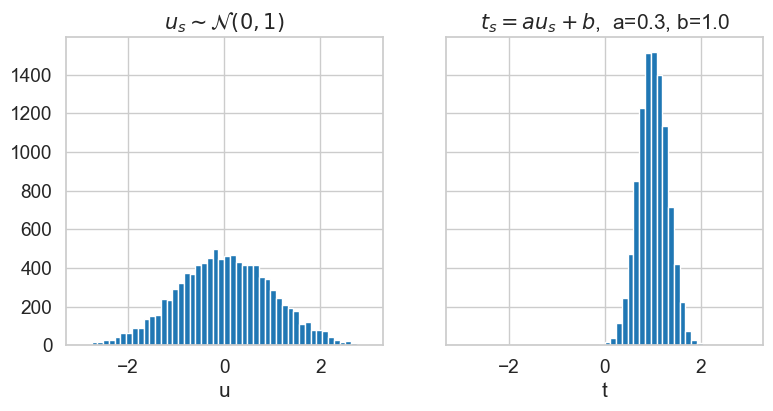

In [ ]:
_, axgrid = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharex=True, sharey=True)
bins = np.linspace(-3, 3, 51)
axgrid[0].hist(u_S, bins=bins); axgrid[0].set_xlabel("u")
axgrid[1].hist(t_S, bins=bins); axgrid[1].set_xlabel("t");

axgrid[0].set_title("$u_s \sim \mathcal{N}(0,1)$");
axgrid[1].set_title("$t_s = a u_s + b$," + f"  a={a:.1f}, b={b:.1f}");

In [ ]:
print("Mean of t  : %.3f" % np.mean(t_S))
print("Stddev of t: %.3f" % np.std(t_S))

Mean of t  : 1.004
Stddev of t: 0.304


A reasonable takeaway is that the proposed linear transformation $T(u) = au + b$ yields a **Normal** over its output values $t$ with mean $b$ and stddev $a$

How could we show this more formally/rigorously?

### Method 2: Theory, via the change of variables formula

Consider random variable $u \in \mathbb{R}$ with known pdf $\color{red}{p(u)}$.

Let deterministic transformation $T(u) : \mathbb{R} \rightarrow \mathbb{R}$ be a one-to-one transformation and thus **invertible**, with its inverse given by function $U(t)$ such that $u = U(T(u))$ for all $u \in \mathbb{R}$.

Well-established theory gives us the Change of Variables formula for defining a PDF directly on the result of the transformation, $t = T(u)$

\begin{align}
\text{pdf}(t) = \color{red}{p(U(t))} \cdot | \frac{\partial}{\partial t} U(t) |
\end{align}

References:

* [Bishop PRML, Sec. 11.1](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf#page=543)

### Worked example for our Normal transformation

\begin{align}
T(u) = au + b
\\
U(t) = \frac{t - b}{a}
\\
\frac{\partial}{\partial t} U(t) = \frac{1}{a}
\end{align}

Then the PDF of $t$ is given by:

\begin{align}
\text{pdf}(t) &= \text{NormPDF}( U(t) | 0, 1) \cdot | \frac{\partial}{\partial t} U(t) |
    \\
    &= \frac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2} \left(\frac{t-b}{a} - 0 \right)^2 \right)
        \cdot \frac{1}{a}
    \\
    &=  \frac{1}{\sqrt{2\pi a^2}} \exp \left( - \frac{1}{2} \frac{1}{a^2} (t-b)^2 \right) 
    \\
    &= \text{NormPDF}( t | b, a^2)
\end{align}

That is, $t$ is provably normally distributed with mean $b$ and standard deviation $a$ (thus variance $a^2$).

Takeaway:   
If we're interested in any Gaussian distribution with mean $\mu$ and stddev $\sigma$, we can draw samples by:

* 1) Drawing $u$ from a standard Normal
* 2) Applying the transform $t \gets \sigma u + \mu$

In other words, we've separated our "source of randomness" (1) from the parameters of our distribution (2)

# Part 2: Reparameterization trick for Expectations

The "reparameterization trick" is really just an application of the change of variables facts above to difficult **expectations**. 

Suppose we have a Gaussian $\mathcal{N}(t | \mu, \sigma^2)$

We wish to compute the following expectation:

\begin{align}
\mathbb{E}_{\mathcal{N}(t | \mu, \sigma^2)} \left[ f (t) \right]
\end{align}

where $f(t) : \mathbb{R} \rightarrow \mathbb{R}$ could be *any* function.

Turns out, we can *alternatively* compute the same thing via an expectation that uses a "standard" Normal random value, plus a transformation:

\begin{align}
\mathbb{E}_{\mathcal{N}(u | 0, 1)} \left[ f (\sigma u + \mu) \right]
\end{align}

**Proof:** Expand the expectation into an integral, and apply a [change of variables (aka integral substitution)](https://en.wikipedia.org/wiki/Integration_by_substitution)

Desired change: $t = \sigma u + \mu$, which implies $\frac{dt}{du} = \sigma$ and $\frac{1}{\sigma} dt=du$

Now substitute these facts into the desired expectation

\begin{align}
\mathbb{E}_{\mathcal{N}(u | 0, 1)} \left[ f (\sigma u + \mu) \right]
&= \int_{u \in \mathbb{R}} f(\sigma u + \mu) \text{NormPDF}(u| 0, 1) du
\\
&= \int_{t \in \mathbb{R}} f(t) \text{NormPDF}( \frac{t - \mu}{\sigma} | 0, 1) \cdot \frac{1}{\sigma} dt
\\
&= \int_{t \in \mathbb{R}} f(t) \text{NormPDF}( t | \mu, \sigma^2) dt
\\
&= \mathbb{E}_{\mathcal{N}(t | \mu, \sigma^2)} \left[ f(t) \right]
\end{align}


# Part 3: Reparameterization Trick for Gradients of Expectations

How does this trick help us in our quest for VI?
We can compute **gradients** of any expectation we can reparameterize.

Suppose we wish to compute a gradient of an expectation with respect to the mean parameter $\mu$ of a Gaussian, like this

\begin{align}
\frac{\partial}{\partial \mu} \mathbb{E}_{\mathcal{N}(t | \mu, \sigma)} \left[ f(t) \right]
\end{align}
where again $f$ is **any** function.

Using the reparameterization trick, we can rewrite the desired quantity in a way that separates the "basic randomness" (in $u$) from the dependence on key parameters $\mu$

\begin{align}
\frac{\partial}{\partial \mu} \mathbb{E}_{\mathcal{N}(u | 0, 1)} \left[ f(\sigma u + \mu) \right]
\end{align}

We can now bring the gradient inside the expectation, and apply the chain rule

\begin{align}
\mathbb{E}_{\mathcal{N}(u | 0, 1)} \left[ \frac{\partial}{\partial \mu} f(\sigma u + \mu) \right]
&= \mathbb{E}_{\mathcal{N}(u | 0, 1)} \left[ \frac{\partial f}{\partial t} \Big|_{t = \sigma u + \mu}
    \cdot \frac{\partial t}{\partial \mu} \Big|_{\mu=\mu}
\right]
\end{align}

Since the "source of randomness" $u$ has been decoupled from the parameter $\mu$, we can then concretely estimate the expectation via an $S$-sample Monte Carlo approximation

\begin{align}
\frac{\partial}{\partial \mu} \mathbb{E}_{\mathcal{N}(t | \mu, \sigma)} \left[ f(t) \right]
&\approx \frac{1}{S} \sum_{s=1}^S
    \left[ \frac{\partial f}{\partial t} \Big|_{t = \sigma u^s + \mu}
    \cdot \frac{\partial t}{\partial \mu} \Big|_{\mu=\mu}
\right],  \qquad u_s \sim \mathcal{N}(0, 1) \text{~for~} s \in 1, 2, \ldots, S
\end{align}

Similarly, a gradient with respect to $\sigma$ can be worked out

\begin{align}
\frac{\partial}{\partial \sigma} \mathbb{E}_{\mathcal{N}(t | \mu, \sigma)} \left[ f(t) \right]
&\approx \frac{1}{S} \sum_{s=1}^S
    \left[ \frac{\partial f}{\partial t} \Big|_{t = \sigma u^s + \mu}
    \cdot \frac{\partial t}{\partial \sigma} \Big|_{\sigma=\sigma}
\right],  \qquad u_s \sim \mathcal{N}(0, 1) \text{~for~} s \in 1, 2, \ldots, S
\end{align}

We could evaluate the inner partial derivatives manually, or we could allow automatic differentiation to do the hard work for us.


# Part 4: How to do gradient descent when variances need to stay positive?

Suppose we're trying to optimize the parameters $\mu, \sigma$ of a Normal distribution to minimize *any* cost function

$$
\min_{\mu \in \mathbb{R}, \sigma \in \mathbb{R}_+} ~~\mathcal{L}( \mu, \sigma)
$$

This cost function could be the negative ELBO, but it could be any other suitable loss you might like.

A natural way to optimize is via first-order gradient descent


<div class="alert alert-warning">
<h3> Algorithm 09-1: Gradient Descent for a mean and standard deviation [BUGGY]
</h3>

1. Initialize to concrete values $\mu_0, \sigma_0$

2. For each iteration $t \in 1, 2, \ldots T$:

3. &nbsp;&nbsp;&nbsp;&nbsp; Estimate the gradient wrt $\mu$: 
$\quad g_t^{\mu} \gets \frac{\partial \mathcal{L}}{\partial \mu}( \mu_t, \sigma_t )
$
4. &nbsp;&nbsp;&nbsp;&nbsp; Estimate the gradient wrt $\sigma$:
$\quad
g_t^{\sigma} \gets \frac{\partial \mathcal{L}}{\partial \sigma}( \mu_t, \sigma_t )
$
5. &nbsp;&nbsp;&nbsp;&nbsp; Update the parameters via a step "downhill"

\begin{align}
\mu_{t+1} &\gets \mu_t - \epsilon g^\mu_t &&\hspace{12cm}
\\
\sigma_{t+1} &\gets \sigma_t - \epsilon g^{\sigma}_t && \text{<- MIGHT GO BAD}
\end{align}


This will work fine in some cases, but it has a potential bug related to the update for $\sigma$

Remember that $\sigma$ is meant to be a **standard deviation**, and thus a strict requirement is that $\sigma > 0$.

Does the update step (line 5 above) guarantee that $\sigma_{t+1} > 0$? No! If $\sigma_t < \epsilon g^{\sigma}_t$, the update could produce a negative value!

This can happen a lot in practice.... a large gradient plus poorly chosen stepsize can spell disaster.

### Fix: reparameterize so all parameters being optimized have unconstrained real values

Luckily, there's an easy fix: **reparameterizing**. 

Instead of writing the loss in terms of $\mu, \sigma$, let's consider an alternative parameterization where $\rho \in \mathbb{R}$ represents an *unconstrained real value* that can be mapped to a positive standard deviation via a deterministic transformation $R : \mathbb{R} \rightarrow \mathbb{R}_+$, so $\sigma \gets R(\rho)$

We're free to select **any** valid transformation, including

\begin{align}
R(\rho) &= \exp \left( \rho \right)             && \text{exponential}
\\
R(\rho) &= \log \left( 1 + \exp( \rho ) \right) && \text{softplus}
\end{align}

Below are some pictures illustrating these functions

## Illustrations of transformations between unconstrained reals and positive reals


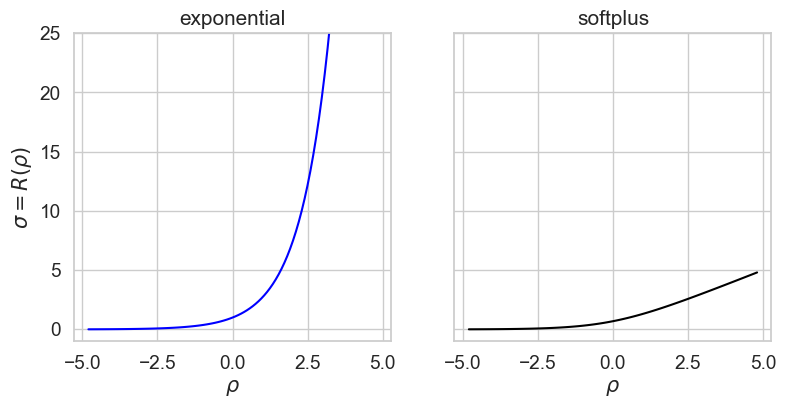

In [ ]:
G = 101
rho_G = np.linspace(-4.8, 4.8, G)

sigA_G = np.exp(rho_G)
sigB_G = np.log(1+np.exp(rho_G))

_, axgrid = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharex=True, sharey=True)
axgrid[0].plot(rho_G, sigA_G, 'b-')
axgrid[1].plot(rho_G, sigB_G, 'k-');
axgrid[0].set_title("exponential"); axgrid[0].set_xlabel(r"$\rho$");
axgrid[1].set_title("softplus"); axgrid[1].set_xlabel(r"$\rho$");
axgrid[0].set_ylabel(r"$\sigma = R(\rho)$"); axgrid[0].set_ylim([-1, 25]);

Either one will work. The softplus is often preferred for numerical computing, because small changes in $\rho$ translate to small changes in $\sigma = R(\rho)$.

## How does this help?

Our optimization problem has changed as follows:

\begin{align}
\min_{\mu \in \mathbb{R}, \sigma \in \mathbb{R}_+} \mathcal{L}(\mu, \sigma)
\rightarrow
\min_{\mu \in \mathbb{R}, \rho \in \mathbb{R}} \mathcal{L}(\mu, R(\rho))
\end{align}

Now, all the parameters are **unconstrained reals** and gradient descent can proceed.

## Improved gradient descent via reparameterization

Using this reparameterization, we can devise a **correct** gradient descent algorithm.

Note that is uses the *chain rule* to compute the gradient for $\rho$

<div class="alert alert-info">
<h3> Algorithm 09-2: Gradient Descent to learn mean and *reparameterized* stddev
</h3>

1. Initialize to concrete values $\mu_0, \rho_0$, set $\sigma_0 \gets R(\rho_0)$

2. For each iteration $t \in 1, 2, \ldots T$:
       
3. &nbsp;&nbsp;&nbsp;&nbsp; Estimate the gradient wrt $\mu$: 
$\quad g_t^{\mu} \gets \frac{\partial \mathcal{L}}{\partial \mu}( \mu_t, \sigma_t )
$
4. &nbsp;&nbsp;&nbsp;&nbsp; Estimate the gradient wrt $\rho$:
$\quad
g_t^{\rho} \gets \frac{\partial \mathcal{L}}{\partial \sigma}( \mu_t, \sigma_t ) \cdot \frac{\partial R}{\partial \rho}(\rho)$
5. &nbsp;&nbsp;&nbsp;&nbsp; Update the parameters via a step "downhill"

\begin{align}
\mu_{t+1} &\gets \mu_t - \epsilon g^\mu_t \hspace{12cm}
\\
\rho_{t+1} &\gets \rho_t - \epsilon g^{\rho}_t
\\
\sigma_{t+1} &\gets R(\rho_{t+1})
\end{align}


It turns out, for algorithms like BBB which you read about, there are really "two" kinds of reparameterization at work.

1. The reparameterization trick to compute gradients of expectations by decoupling "elementary randomness" from dependence on parameters
2. Another reparameterization of variance parameters, so that unconstrained gradient descent can be used

# Part 5: Bayes by backprop for Neural Nets

Blundell et al. define an Algorithm for fitting posteriors for supervised neural net problems.

See the pseudocode in Sec 3.2 here: https://proceedings.mlr.press/v37/blundell15.pdf#page=4

We've adapted this into the neural net notation used in this class below.

### Model

Prior $p(w)$ over neural nets with weights $w$

Likelihood $p(y_{1:N}|w)$ for observed outputs $y_1, \ldots y_N$ given fixed inputs $x_1 \ldots x_N$

### Variational approximate posterior

We use a fully-factorized Normal: $q(w) = \prod_{j} \mathcal{N}(w_{j} | \mu_{j}, R(\rho_j) )$


<div class="alert alert-info">
<h3> Algorithm 09-3: Bayes-by-Backprop
</h3>

1. Initialize $\{\mu_j, \rho_j\}_{j=1}^J$

2. For each iteration $t \in 1, 2, \ldots T$:

3. &nbsp;&nbsp;&nbsp;&nbsp; Sample from standard normal: $\epsilon^s \sim \mathcal{N}(0,I)$
    
4. &nbsp;&nbsp;&nbsp;&nbsp; Estimate a 1-sample gradient wrt $\mu$:
    
\begin{align}
\nabla_\mu \log p( y_{1:N} | )
\end{align}
    
4. &nbsp;&nbsp;&nbsp;&nbsp; Estimate the gradient wrt $\rho$:
$\quad
g_t^{\rho} \gets \frac{\partial \mathcal{L}}{\partial \sigma}( \mu_t, \sigma_t ) \cdot \frac{\partial R}{\partial \rho}(\rho)$
5. &nbsp;&nbsp;&nbsp;&nbsp; Update the parameters via a step "downhill"

\begin{align}
\mu_{t+1} &\gets \mu_t - \epsilon g^\mu_t \hspace{12cm}
\\
\rho_{t+1} &\gets \rho_t - \epsilon g^{\rho}_t
\\
\sigma_{t+1} &\gets R(\rho_{t+1})
\end{align}


# Part 6: Automatic Differentiation Variational Inference (ADVI)

Turns out, Bayes-by-Backprop is a special case (focused on neural networks) of a broader algorithm called Automatic Differentiation VI (ADVI).

See Alg. 1 here: https://www.jmlr.org/papers/volume18/16-107/16-107.pdf#page=11

Essentially, ADVI shows how to use the core ideas from BBB (gradients of the ELBO via the reparameterization trick) for a much broader family of models: essentially any where all variables are continuous and the log prior and log likelihood are differentiable.

# Part 7: Comparison of Reparameterization trick and Score Function trick estimators

In [ ]:
prng = np.random.RandomState(101)

true_tau = 0.8

N = 100

x_N = prng.uniform(size=N, low=-3, high=+3)
y_N = prng.normal(x_N, true_tau)

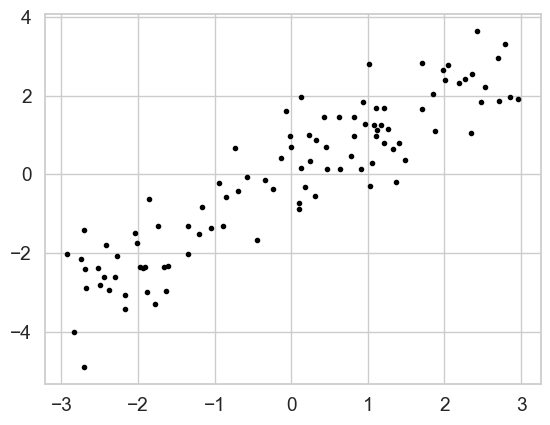

In [ ]:
plt.plot(x_N, y_N, 'k.');

### Define model

In [ ]:
class ToyModel:

    @classmethod
    def calc_logpdf_prior__S(self, z_SL):
        ''' Compute logpdf of prior at each of S samples of z
        
        Returns
        -------
        logpdf_S : 1D array, size (S,)
        '''
        return jnp.sum(jstats.norm.logpdf(z_SL, 0.0, 1.0), axis=1)
    
    @classmethod
    def calc_logpdf_likelihood__S(self, z_SL, y_N, x_N, tau=true_tau):
        ''' Compute logpdf of likelihood at each of S samples of z

        Returns
        -------
        logpdf_S : 1D array, size (S,)
        '''
        x_N1 = x_N[:,np.newaxis]
        prodz_1S = (z_SL[:,0] * z_SL[:,1])[jnp.newaxis,:]
        mean_NS = x_N1 * prodz_1S
        return jnp.sum(jstats.norm.logpdf(y_N[:,jnp.newaxis], mean_NS, tau), axis=0)

In [ ]:
ToyModel.fast_logpdf_likelihood__S = jax.jit(ToyModel.calc_logpdf_likelihood__S)
ToyModel.fast_logpdf_prior__S = jax.jit(ToyModel.calc_logpdf_prior__S)

In [ ]:
ToyModel.fast_logpdf_likelihood__S = jax.jit(ToyModel.calc_logpdf_likelihood__S)
ToyModel.fast_logpdf_prior__S = jax.jit(ToyModel.calc_logpdf_prior__S)


## Define q

$$
q( z_0, z_1; \nu ) = \mathcal{N}( z_0 | \mu_0, 0.3^2 ) \mathcal{N}( z_1 | \mu_1, 0.3^2 )
$$

* mean parameter vector $\nu = [\mu_0, \mu_1]$ is what we intend to learn
* for now, we'll treat the posterior variance as "small" and fixed to 0.09

Ultimate goal: find settings of $\nu = [\mu_0, \mu_1]$ such that 

$$
q( z_0, z_1; \nu ) \approx p( z_0, z_1 | x_{1:N} )
$$

In [ ]:
class QNormalFixedVariance:

    fixed_stddev = 0.3

    @classmethod
    def calc_sum_logpdf_q(self, z_SL, q_params):
        ''' Compute logpdf of q summed over S provided samples of z
        
        Returns
        -------
        logpdf : scalar float
        '''
        mu_L = q_params
        return jnp.sum(jstats.norm.logpdf(z_SL, mu_L[jnp.newaxis,:], self.fixed_stddev))
        
    @classmethod
    def calc_logpdf_q__S(self, z_SL, q_params, return_array=False):
        ''' Compute logpdf of q at each of S provided samples of z
        
        Returns
        -------
        logpdf : 1D array (S,)
        '''
        mu_L = q_params
        return jnp.sum(jstats.norm.logpdf(z_SL, mu_L[jnp.newaxis,:], self.fixed_stddev), axis=1)
        
    @classmethod
    def sample_z(self, q_params, random_state, n_samples=1):
        mu_L = q_params
        return random_state.normal(mu_L, self.fixed_stddev, size=(n_samples,) + mu_L.shape)

    @classmethod
    def transform_u_samples_to_z(self, u_SL, q_params):
        L = u_SL.shape[1]
        mu_1L = q_params.reshape(1,L)
        return self.fixed_stddev * u_SL + mu_1L
    
    @classmethod
    def initialize(self, z_shape, random_state=101):
        return np.zeros(z_shape)

In [ ]:
QNormalFixedVariance.fast_logpdf_q__S = jax.jit(QNormalFixedVariance.calc_logpdf_q__S)

In [ ]:
QNormalFixedVariance.fast_logpdf_q__S = jax.jit(QNormalFixedVariance.calc_logpdf_q__S)

## ELBO calculation

In [ ]:
def calc_ELBO_via_montecarlo(q_params, Model, Q, n_samples=100, random_state=np.random):
    z_SL = Q.sample_z(q_params, n_samples=n_samples, random_state=random_state)
    
    Eq_logpdf_lik_S = Model.fast_logpdf_likelihood__S(z_SL, y_N, x_N)
    Eq_logpdf_prior_S = Model.fast_logpdf_prior__S(z_SL)
    Eq_logpdf_q_S = Q.fast_logpdf_q__S(z_SL, q_params)
    
    elbo_S = Eq_logpdf_lik_S + Eq_logpdf_prior_S - Eq_logpdf_q_S
    return jnp.mean(elbo_S)

## Gradient calculation via SCORE FUNCTION TRICK

In [ ]:
def calc_grad_of_logpdf_q__SL(z_SL, nu_L):
    # Calculate gradient wrt SECOND argument (argnums=1 when counting from zero)
    grad_wrt_nu = jax.grad(QNormalFixedVariance.calc_sum_logpdf_q, argnums=1)
    vectorized_grad_wrt_nu = jax.vmap(grad_wrt_nu)
    S = z_SL.shape[0]
    nu_SL = jnp.tile(nu_L, (S,1))
    return vectorized_grad_wrt_nu(z_SL, nu_SL)

def calc_grad_of_ELBO__score_func_trick(q_params, Model, Q, n_samples=100, random_state=np.random):
    z_SL = Q.sample_z(q_params, n_samples=n_samples, random_state=random_state)
    
    Eq_logpdf_lik_S = Model.fast_logpdf_likelihood__S(z_SL, y_N, x_N)
    Eq_logpdf_prior_S = Model.fast_logpdf_prior__S(z_SL)
    Eq_logpdf_q_S = Q.fast_logpdf_q__S(z_SL, q_params)
    
    elbo_S = Eq_logpdf_lik_S + Eq_logpdf_prior_S - Eq_logpdf_q_S

    g_SL = calc_grad_of_logpdf_q__SL(z_SL, q_params)
    
    return jnp.mean(g_SL * elbo_S[:,jnp.newaxis], axis=0)

In [ ]:
fast_grad_of_ELBO__score_func_trick = jax.jit(calc_grad_of_ELBO__score_func_trick)

## Gradient calculation via REPARAMETERIZATION TRICK

In [ ]:
def calc_ELBO_from_u(u_SL, q_params, Model, Q):
    z_SL = Q.transform_u_samples_to_z(u_SL, q_params)    
    Eq_logpdf_lik_S = Model.fast_logpdf_likelihood__S(z_SL, y_N, x_N)
    Eq_logpdf_prior_S = Model.fast_logpdf_prior__S(z_SL)
    Eq_logpdf_q_S = Q.fast_logpdf_q__S(z_SL, q_params)    
    elbo_S = Eq_logpdf_lik_S + Eq_logpdf_prior_S - Eq_logpdf_q_S
    return jnp.mean(elbo_S)
calc_grad_of_ELBO_from_u = jax.grad(calc_ELBO_from_u, argnums=[1])

def calc_grad_of_ELBO__reparam_trick(q_params, Model, Q, n_samples=100, random_state=np.random):
    S = int(n_samples)
    L = q_params.shape[0]
    u_SL = random_state.randn(S, L)
    return calc_grad_of_ELBO_from_u(u_SL, q_params, Model, Q)[0]

In [ ]:
fast_grad_of_ELBO__reparam_trick = jax.jit(calc_grad_of_ELBO__reparam_trick)

## Evaluate quality of gradients side by side, over several trials

In [ ]:
nu_allones_L = jnp.ones(2)

In [ ]:
T = 500 # n_trials
L = 2

S_list = [1, 10, 100, 500]
grad_TL_by_method = {}

for method_name, calc_grad_func in [
        ('score func trick', calc_grad_of_ELBO__score_func_trick),
        ('reparam trick', calc_grad_of_ELBO__reparam_trick),
        ]:
    for S in S_list:
        grad_TL_by_method[(S,method_name)] = np.zeros((T, L))   
        print("S: ", S, ", method: ", method_name)
        for rep in range(T):
            prng = np.random.RandomState(1010 + rep)
            grad_wrt_nu_L = calc_grad_func(nu_allones_L, ToyModel, QNormalFixedVariance, S, prng)
            grad_TL_by_method[(S,method_name)][rep, :] = grad_wrt_nu_L

S:  1 , method:  score func trick


S:  10 , method:  score func trick


S:  100 , method:  score func trick


S:  500 , method:  score func trick


S:  1 , method:  reparam trick


S:  10 , method:  reparam trick


S:  100 , method:  reparam trick


S:  500 , method:  reparam trick


In [ ]:
method_name

'reparam trick'

In [ ]:
row_dict_list = list()
for S in S_list:
    for method_name in ['score func trick', 'reparam trick']:
        mean_grad_L = np.mean(grad_TL_by_method[(S,method_name)], axis=0)
        lo_grad_L = np.percentile(grad_TL_by_method[(S, method_name)], 2.5, axis=0)
        hi_grad_L = np.percentile(grad_TL_by_method[(S, method_name)], 97.5, axis=0)
    
        row_dict = dict(S=S, method_name=method_name,
            mean_g_wrt_mu0=mean_grad_L[0],
            lo_g_wrt_mu0=lo_grad_L[0],
            hi_g_wrt_mu0=hi_grad_L[0], 
            mean_g_wrt_mu1=mean_grad_L[1],
            lo_g_wrt_mu1=lo_grad_L[1], 
            hi_g_wrt_mu1=hi_grad_L[1])
        row_dict_list.append(row_dict)
df = pd.DataFrame(row_dict_list)

In [ ]:
pd.set_option("display.precision", 2)
df

,S,method_name,mean_g_wrt_mu0,lo_g_wrt_mu0,hi_g_wrt_mu0,mean_g_wrt_mu1,lo_g_wrt_mu1,hi_g_wrt_mu1
0,1,score func trick,-32.37,-1709.09,1399.71,10.09,-1428.24,1424.16
1,1,reparam trick,-21.56,-538.50,263.58,-20.88,-570.72,284.21
2,10,score func trick,-37.59,-616.08,425.99,-27.41,-534.90,423.19
3,10,reparam trick,-30.68,-188.00,103.44,-31.55,-194.60,92.10
4,100,score func trick,-30.08,-207.60,115.39,-30.65,-185.78,112.42
5,100,reparam trick,-30.41,-71.00,15.59,-30.77,-71.35,9.85
6,500,score func trick,-31.89,-104.14,29.91,-31.92,-106.59,36.86
7,500,reparam trick,-30.89,-50.67,-12.64,-31.10,-51.17,-12.96


## Concept questions

* Do both estimators seem to give the same gradient?
* Which estimator has tighter (lo,hi) intervals at a given S?